# Intelligent Agents

This notebook was created when I was studying the LangChain library based in the book **Generative AI with LangChain, Second Edition** of the authors *Bean Aufffart* and *Leonid Kuligin*. The book is based on LangChain version 0.37, but this code is based on 1.2.10.

## Preparing the API to Google's Gemini, OpenAI and others

I only have an API key for Google's Gemini, so every example will run on that model or in local model. The file that configures needs to contain the following code:

```python
import os

GOOGLE_API_KEY = "..."

def set_environment():
    variable_dict = globals().items()

    for key, value in variable_dict:
        if "API" in key or "ID" in key or "GOOGLE" in key:
            os.environ[key] = value
```

I will not upload this file to not risk of leak my own API key. The file `config.py` is listed on `.gitignore`.

So, all you need to do is to run the following code to enable all the API keys required to this notebook.

In [3]:
# setting the environment variables, the keys
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

from config import set_environment
# for the keys - as explained early in chapter 2
set_environment()

Here we develop a pseudo tool invocation, so we can see how to chain multiple tools invokations, even that we are not running any tool by now.

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

raw_prompt_template = (
  "You have access to search engine that provides you an "
  "information about fresh events and news given the query. "
  "Given the question, decide whether you need an additional "
  "information from the search engine (reply with 'SEARCH: "
   "<generated query>' or you know enough to answer the user "
   "then reply with 'RESPONSE <final response>').\n"
   "Do not make any assumptions on recent events or things that can change."
   "Now, act to answer a user question:\n{QUESTION}"
)
prompt_template = PromptTemplate.from_template(raw_prompt_template)

## Here we are asking a question based in the internal knowledge
question1 = "What is the capital of Germany?"
result = (prompt_template | llm).invoke(question1)
print(result.content)

## Here the llm answer request that we search for the age of the US president in an external resource.
question = "how old is the US president?"
response = (prompt_template | llm).invoke(question)
print(response.content)

## This simulates a query based in the response from the previous invokation
query = "age of current US president"
search_result = (
    "Donald Trump › Age 78 years June 14, 1946\n"
    "Donald Trump 45th and 47th U.S. President Donald John Trump is an American "
    "politician, media personality, and businessman who has served as the 47th "
    "president of the United States since January 20, 2025. A member of the "
    "Republican Party, he previously served as the 45th president from 2017 to 2021. Wikipedia"
)

raw_prompt_template = (
  "You have access to search engine that provides you an "
  "information about fresh events and news given the query. "
  "Given the question, decide whether you need an additional "
  "information from the search engine (reply with 'SEARCH: "
   "<generated query>' or you know enough to answer the user "
   "then reply with 'RESPONSE <final response>').\n"
   "Today is {date}."
   "Now, act to answer a user question and "
   "take into account your previous actions:\n"
   "HUMAN: {question}\n"
   "AI: SEARCH: {query}\n"
   "RESPONSE FROM SEARCH: {search_result}\n"
)
prompt_template = PromptTemplate.from_template(raw_prompt_template)

result = (prompt_template | llm).invoke({"question": question, "query": query, "search_result": search_result, "date": "Feb 2025"})
print(result.content)

RESPONSE The capital of Germany is Berlin.
SEARCH: age of current US president
RESPONSE Donald Trump is 78 years old.


Now, let's execute the same process, but calling an external tools instead:

In [5]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage

llm = ChatOpenAI()
question = "how old is the US president?"

search_tool = {
    "type": "function",
    "function": {
        "name": "google_search",
        "description": "Returns about common facts, fresh events and news from Google Search engine based on a query.",
        "parameters": {
            "type": "object",
            "properties": {
                "query": {
                    "type": "string",
                    "title": "search_query",
                    "description": "Search query to be sent to the search engine"
                }
            },
            "required": ["query"]
        }
    }
}
step1 = llm.invoke(question, tools=[search_tool])

print(step1.content)
print(step1.tool_calls)

tool_result = ToolMessage(content="Donald Trump › Age 78 years June 14, 1946\n", tool_call_id=step1.tool_calls[0]["id"])
step2 = llm.invoke(
    [HumanMessage(content=question), step1, tool_result],
    tools=[search_tool]
)
assert len(step2.tool_calls) == 0

print(step2.content)


[{'name': 'google_search', 'args': {'query': 'age of the current US president'}, 'id': 'call_U7x7OTqV4DvNrewwE0GQmPej', 'type': 'tool_call'}]
The current US President, Donald Trump, is 78 years old. He was born on June 14, 1946.


## ReACT

This is a design pattern that involves Reasoning and ACT.

Reason: Generate a text output with observations about the current situation and a plan to solve the task
Act: Take an action based on the reasoning above.

In [6]:
import math
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder


## Prepare the tools
def  mocked_google_search(query: str) -> str:
    print(f"CALLED GOOGLE SEARCH with query={query}")
    return "Donald Trump is a president of USA and he's 78 years old"

def mocked_calculator(expression: str) -> float:
    print(f"CALLED CALCULATOR with expression={expression}")
    if "sqrt" in expression:
        return math.sqrt(78*132)
    return 78*123

calculator_tool = {
    "type": "function",
    "function": {
        "name": "calculator",
        "description": "Computes mathematical expressions",
        "parameters": {
            "type": "object",
            "properties": {
                "expression": {
                    "type": "string",
                    "title": "expression",
                    "description": "A mathematical expression to be evaluated by a calculator"
                }
            },
            "required": ["expression"]
        }
    }
}

search_tool = {
    "type": "function",
    "function": {
        "name": "google_search",
        "description": "Returns about common facts, fresh events and news from Google Search engine based on a query.",
        "parameters": {
            "type": "object",
            "properties": {
                "query": {
                    "type": "string",
                    "title": "search_query",
                    "description": "Search query to be sent to the search engine"
                }
            },
            "required": ["query"]
        }
    }
}

prompt = ChatPromptTemplate.from_messages([
    ("system", """ Always use a calculator for mathematical computations, and use Google Search
                   for information about common facts, fresh events and news. Do not assume anything, keep in
                   mind that things are changing and always
                   check yourself with external sources if possible.
               """)
])

llm_with_tools = llm.bind(tools=[search_tool, calculator_tool])

## Prepare the tool invocations
from langchain_core.messages import HumanMessage, ToolMessage
from langgraph.graph import MessagesState, StateGraph, START, END


def invoke_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


def call_tools(state: MessagesState):
    last_message = state["messages"][-1]
    tool_calls = last_message.tool_calls

    new_messages = []

    for tool_call in tool_calls:
      if tool_call["name"] == "google_search":
        tool_result = mocked_google_search(**tool_call["args"])
        new_messages.append(ToolMessage(content=tool_result, tool_call_id=tool_call["id"]))
      elif tool_call["name"] == "calculator":
        tool_result = mocked_calculator(**tool_call["args"])
        new_messages.append(ToolMessage(content=tool_result, tool_call_id=tool_call["id"]))
      else:
        raise ValueError(f"Tool {tool_call['name']} is not defined!")
    return {"messages": new_messages}


def should_run_tools(state: MessagesState):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
      return "call_tools"
    return END

builder = StateGraph(MessagesState)
builder.add_node("invoke_llm", invoke_llm)
builder.add_node("call_tools", call_tools)

builder.add_edge(START, "invoke_llm")
builder.add_conditional_edges("invoke_llm", should_run_tools)
builder.add_edge("call_tools", "invoke_llm")

graph = builder.compile()

question = "What is a square root of the current US president's age multiplied by 132?"

result = graph.invoke({"messages": [HumanMessage(content=question)]})
print(result["messages"][-1].content)

CALLED CALCULATOR with expression=sqrt(46 * 132)
The square root of the current US president's age multiplied by 132 is approximately 101.47.


Do The same thing, with lang graph:

In [7]:
from langgraph.prebuilt import create_react_agent
from langchain_core.tools import tool


@tool("google_search")
def mocked_google_search_tool(query: str) -> str:
    """Returns about common facts, fresh events and news from Google Search engine based on a query."""
    return mocked_google_search(query)


@tool("calculator")
def mocked_calculator_tool(expression: str) -> str:
    """Computes mathematical expressions"""
    return str(mocked_calculator(expression))

system_prompt = (
    "Always use a calculator for mathematical computations, and use Google Search "
    "for information about common facts, fresh events and news. Do not assume anything, keep in "
    "mind that things are changing and always "
    "check yourself with external sources if possible."
)


agent = create_react_agent(
    model=llm,
    tools=[mocked_google_search_tool, mocked_calculator_tool],
    prompt=system_prompt,
)

agent_result = agent.invoke({"messages": [HumanMessage(content=question)]})
print(agent_result["messages"][-1].content)

/var/folders/8c/k0d1bjq91qb_m_1nbm26xh500000gn/T/ipykernel_71009/22867269.py:24: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


CALLED CALCULATOR with expression=sqrt(75*132)
The square root of the current US president's age multiplied by 132 is approximately 101.47.


## Tools

Now, we will enter in details how to integrate tools.

In [8]:
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_community.tools.ddg_search.tool import DDGInput

search = DuckDuckGoSearchRun( api_wrapper_kwargs={"backend": "api"} )
print(f"Tool's name = {search.name}")

print(f"Tool's description = {search.description}")
print(f"Tool's arg schema = {search.args_schema}")

print(DDGInput.model_fields)

query = "What is the weather in Munich like tomorrow?"

search_input = DDGInput(query = query)

result = search.invoke(search_input.model_dump())

print("Invoke with tool")
print(result)

result = llm.invoke([("system", "Always use a duckduckgo_search tool for queries that require a fresh information"), ("user", query)], tools=[search])
print("Invoke with LLM")
print(result.tool_calls[0])

Tool's name = duckduckgo_search
Tool's description = A wrapper around DuckDuckGo Search. Useful for when you need to answer questions about current events. Input should be a search query.
Tool's arg schema = <class 'langchain_community.tools.ddg_search.tool.DDGInput'>
{'query': FieldInfo(annotation=str, required=True, description='search query to look up')}


Impersonate 'firefox_109' does not exist, using 'random'


Invoke with tool
1 day ago · Get the latest hourly weather updates for Munich tomorrow . Detailed forecast including temperature, wind, rain, snow, and UV index. Stay informed about tomorrow 's weather conditions in Munich . 3 days ago · Munich , Germany - Detailed weather forecast for tomorrow . Hourly forecast for tomorrow - including weather conditions, temperature, pressure, humidity, precipitation, dewpoint, wind, visibility, and UV index data. Be prepared with the most accurate 10-day forecast for Munich , Bavaria, Germany with highs, lows, chance of precipitation from The Weather Channel and Weather.com Hourly weather forecast in Munich , Bavaria, Germany. Check current conditions in Munich , Bavaria, Germany with radar, hourly, and more. Today's and tonight's professional weather forecast for Munich . Precipitation radar, HD satellite images, and current weather warnings, hourly temperature, chance of rain, and sunshine hours.


BadRequestError: Error code: 400 - {'error': {'message': "Missing required parameter: 'tools[0].type'.", 'type': 'invalid_request_error', 'param': 'tools[0].type', 'code': 'missing_required_parameter'}}

Now, let's create our first agent

/var/folders/8c/k0d1bjq91qb_m_1nbm26xh500000gn/T/ipykernel_71009/2368337475.py:7: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(model=llm, tools=[search], prompt="Always use a duckduckgo_search tool for queries that require a fresh information")


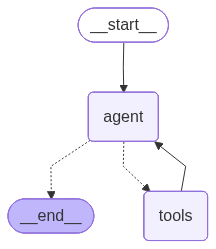

================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (call_VASSljOW4tKJNYy9mwr9QTET)
 Call ID: call_VASSljOW4tKJNYy9mwr9QTET
  Args:
    query: a última viagem do presidente Lula
================================= Tool Message =================================
Name: duckduckgo_search

2 weeks ago - O número de visitas por país onde o presidente Lula viajou em seu terceiro mandato na presidência são: Uma viagem: África do Sul, Alemanha, Angola, Arábia Saudita, Bélgica, Bolívia, Catar, Cabo Verde, Canadá, Coreia do Sul, Cuba, Egito, Espanha, Etiópia, Guiana, Honduras, Indonésia, Malásia, México, Moçambique, Mônaco, Panamá, Portugal, Reino Unido, Rússia, São Vicente e Granadinas, São Tomé e Príncipe, Suíça e Vietnã 2 weeks ago - O ministro da Agricultura, Carlos Fávaro, afirmou nessa sexta-feira (6/3) que a viagem do presidente Luiz Inácio Lula da Silva aos Estados Unidos, prevista para a segunda quinzena de março, foi suspensa de

In [9]:
from langgraph.prebuilt import create_react_agent
from IPython.display import Image, display

query = "What is the weather in Munich like tomorrow?"
query = "Qual a ultima viagem do president Lula?"

agent = create_react_agent(model=llm, tools=[search], prompt="Always use a duckduckgo_search tool for queries that require a fresh information")

display(Image(agent.get_graph().draw_mermaid_png()))

for event in agent.stream({ "messages" : [("user", query)]}):
    update = event.get("agent", event.get("tools", {}))

    for message in update.get("messages", []):
      message.pretty_print()

## API Call

This example on how to invoke an API using LangChain.

This is the API descriptor, based on OpenAPI format:

In [11]:
from langchain_community.agent_toolkits.openapi.toolkit import RequestsToolkit
from langchain_community.utilities.requests import TextRequestsWrapper

toolkit = RequestsToolkit(
    requests_wrapper=TextRequestsWrapper(headers={}),
    allow_dangerous_requests=True,
)

for tool in toolkit.get_tools():
    print(tool.name)

api_spec = """
openapi: 3.0.0
info:
  title: Frankfurter Currency Exchange API
  version: v1
  description: API for retrieving currency exchange rates. Pay attention to the base currency and change it if needed.

servers:
  - url: https://api.frankfurter.dev/v1

paths:
  /v1/{date}:
    get:
      summary: Get exchange rates for a specific date.
      parameters:
        - in: path
          name: date
          schema:
            type: string
            pattern: '^\d{4}-\d{2}-\d{2}$' # YYYY-MM-DD format
          required: true
          description: The date for which to retrieve exchange rates.  Use YYYY-MM-DD format.  Example: 2009-01-04
        - in: query
          name: symbols
          schema:
            type: string
          description: Comma-separated list of currency symbols to retrieve rates for. Example: GBP,USD,EUR

  /v1/latest:
    get:
      summary: Get the latest exchange rates.
      parameters:
        - in: query
          name: symbols
          schema:
            type: string
          description: Comma-separated list of currency symbols to retrieve rates for. Example: CHF,GBP
        - in: query
          name: base
          schema:
            type: string
          description: The base currency for the exchange rates. If not provided, EUR is used as a base currency. Example: USD
"""

requests_get
requests_post
requests_patch
requests_put
requests_delete


<>:31: SyntaxWarning: invalid escape sequence '\d'
<>:31: SyntaxWarning: invalid escape sequence '\d'
/var/folders/8c/k0d1bjq91qb_m_1nbm26xh500000gn/T/ipykernel_71009/30214476.py:31: SyntaxWarning: invalid escape sequence '\d'
  pattern: '^\d{4}-\d{2}-\d{2}$' # YYYY-MM-DD format


Building the ReACT agent:

In [13]:
from langchain.agents import create_agent

system_message = (
    "You're given the API spec: \n{api_spec}\n"
    "Use the API to answer user's queries if possible."
)

agent = create_agent(llm, toolkit.get_tools(), system_prompt=system_message.format(api_spec=api_spec))

query = "What is the brazilian real to US dollar exchange rate?"

events = agent.stream(
    { "messages" : [("user", query)]},
    stream_mode="values",
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

What is the brazilian real to US dollar exchange rate?
================================== Ai Message ==================================
Tool Calls:
  requests_get (call_AEcyUlfIXYLYOLPXSjYaR52e)
 Call ID: call_AEcyUlfIXYLYOLPXSjYaR52e
  Args:
    url: https://api.frankfurter.dev/v1/latest?symbols=USD&base=BRL
================================= Tool Message =================================
Name: requests_get

{"amount":1.0,"base":"BRL","date":"2026-03-20","rates":{"USD":0.19029}}
================================== Ai Message ==================================

As of the latest data available (March 20, 2026), the exchange rate from Brazilian Real (BRL) to US Dollar (USD) is 1 BRL to 0.19029 USD.


Now, I will create a custom tool: a calculator

In [25]:
import math

from langchain_core.tools import tool
import numexpr as ne

@tool
def calculator(expression: str) -> str:
    """
    Calculates a single mathematical expression, incl. complex numbers.
    Always add * to operations, example:
    73i -> 73*i
    7pi**2 -> 7*pi**2
    """
    math_constants = {"pi": math.pi, "i": 1j , "e": math.e}

    result = ne.evaluate(expression.strip(), local_dict=math_constants)

    return str(result)

from langchain_core.tools import BaseTool

assert isinstance(calculator, BaseTool)
print(f"Tool name: {calculator.name}")
print(f"Tool description: {calculator.description}")
print(f"Tool schema: {calculator.args_schema.model_json_schema()}")

Tool name: calculator
Tool description: Calculates a single mathematical expression, incl. complex numbers.
Always add * to operations, example:
73i -> 73*i
7pi**2 -> 7*pi**2
Tool schema: {'description': 'Calculates a single mathematical expression, incl. complex numbers.\nAlways add * to operations, example:\n73i -> 73*i\n7pi**2 -> 7*pi**2', 'properties': {'expression': {'title': 'Expression', 'type': 'string'}}, 'required': ['expression'], 'title': 'calculator', 'type': 'object'}


Test the calculator tool:

In [27]:
query = "How much is 2+3*i squared?"

agent = create_agent(llm, [ calculator ])

for event in agent.stream({ "messages" : [("user", query)]}, stream_mode="values",):
    event["messages"][-1].pretty_print()


================================ Human Message =================================

How much is 2+3*i squared?
================================== Ai Message ==================================
Tool Calls:
  calculator (call_gHo2hxtAXHrtfubIFx4wQicq)
 Call ID: call_gHo2hxtAXHrtfubIFx4wQicq
  Args:
    expression: (2+3*i)**2
================================= Tool Message =================================
Name: calculator

(-5+12j)
================================== Ai Message ==================================

The result of (2+3i) squared is -5+12i.


In [24]:
math_constants = {"pi": math.pi, "i": 1j, "e": math.exp}
ne.evaluate("(2+3*i)**2", local_dict=math_constants)

array(-5.+12.j)

In [31]:
question = "What is a square root of the current Us president's age multiplied by 132?"

system_hint = "Think step-by-step. Always use search to get the fresh information about events or public facts that can change over time."

agent = create_agent(llm, [ calculator, search ], system_prompt=system_hint)

for event in agent.stream({ "messages" : [("user", question)]}, stream_mode="values"):
    event["messages"][-1].pretty_print()

print(event["messages"][-1].content)

================================ Human Message =================================

What is a square root of the current Us president's age multiplied by 132?
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (call_KjINCA4kQufdGrLpKILKRcQz)
 Call ID: call_KjINCA4kQufdGrLpKILKRcQz
  Args:
    query: current Us president's age
================================= Tool Message =================================
Name: duckduckgo_search

The first table charts the age of each president of the United States at the time of their inauguration, upon leaving office, and at the time of death. Presidents who are still living have their lifespans and post- presidency timespans calculated through March 18, 2026. Learn about the duties of the U . S . president , vice president , and first lady. Find out how to contact and learn more about current and past leaders. There have been 46 presidents of the United States . The youngest president was J

## Structured Output

This si how to create a structured output, using LangChain, and tools.

First create the model:

In [35]:
from pydantic import BaseModel, Field
from langchain_core.prompts import PromptTemplate

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

class Step(BaseModel):
    """A step that is a part of the plan to solve the task."""
    step: str = Field(description="Description of the step")


class Plan(BaseModel):
    """A plan to solve the task."""
    steps: list[Step]


prompt = PromptTemplate.from_template(
    "Prepare a step-by-step plan to solve the given task.\n"
    "TASK:\n{task}\n"
)

result = (prompt | llm.with_structured_output(Plan)).invoke("How to write a bestseller on Amazon about generative AI?")
assert isinstance(result, Plan)
print(f"Amount of steps: {len(result.steps)}")
for step in result.steps:
  print(step.step)
  break



Amount of steps: 15
Conduct thorough market research on Amazon to identify popular sub-niches within generative AI, analyze existing bestsellers, and understand reader demand and gaps.
Define your unique angle and target audience for the book, focusing on a specific problem or aspect of generative AI you can address better than competitors.
Outline the book's structure, including chapters, key topics, and a compelling narrative flow that educates, entertains, or provides practical value.
Write engaging and informative content, ensuring accuracy, clarity, and originality, potentially including case studies, examples, or practical applications of generative AI.
Hire professional editors and proofreaders to ensure the manuscript is polished, error-free, and adheres to high literary standards.
Design a professional and eye-catching book cover that clearly communicates the book's topic and appeals to your target audience.
Format the manuscript for Amazon Kindle Direct Publishing (KDP) for b

Same, but use JSOn mode

In [38]:
plan_schema = {
    "type": "ARRAY",
    "items": {
        "type": "OBJECT",
          "properties": {
              "step": {"type": "STRING"},
          },
      },
}

query = "How to write a bestseller on Amazon about generative AI?"
result = (prompt | llm.with_structured_output(schema=plan_schema, method="json_mode")).invoke(query)

assert(isinstance(result, list))
print(f"Amount of steps: {len(result)}")
print(result[0])

Amount of steps: 13
{'step': 'Conduct thorough market research to identify a specific niche or angle within generative AI that is underserved or highly in demand. Analyze existing bestsellers on Amazon in related categories to understand what resonates with readers.'}


## Full plan and solve agent with structure output.

Here create the model:

In [39]:
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI


class Plan(BaseModel):
    """Plan to follow in future"""

    steps: list[str] = Field(
        description="different steps to follow, should be in sorted order"
    )


system_prompt_template = (
    "For the given task, come up with a step by step plan.\n"
    "This plan should involve individual tasks, that if executed correctly will "
    "yield the correct answer. Do not add any superfluous steps.\n"
    "The result of the final step should be the final answer. Make sure that each "
    "step has all the information needed - do not skip steps."
)
planner_prompt = ChatPromptTemplate.from_messages(
    [("system", system_prompt_template),
     ("user", "Prepare a plan how to solve the following task:\n{task}\n")])

planner = planner_prompt | ChatGoogleGenerativeAI(
    model="gemini-2.5-flash", temperature=1.0
).with_structured_output(Plan)

Create and configure the tools:

In [40]:
from pydantic import BaseModel, Field
from langchain_core.runnables import RunnableLambda, RunnableConfig
from langchain_core.tools import tool, convert_runnable_to_tool
import numexpr as ne


class CalculatorArgs(BaseModel):
    expression: str = Field(description="Mathematical expression to be evaluated")

def calculator(state: CalculatorArgs, config: RunnableConfig) -> str:
    expression = state["expression"]
    math_constants = config["configurable"].get("math_constants", {})
    result = ne.evaluate(expression.strip(), local_dict=math_constants)
    return str(result)


calculator_with_retry = RunnableLambda(calculator).with_retry(
    wait_exponential_jitter=True,
    stop_after_attempt=3,
)

calculator_tool = convert_runnable_to_tool(
    calculator_with_retry,
    name="calculator",
    description=(
        "Calculates a single mathematical expression, incl. complex numbers."
        "'\nAlways add * to operations, examples:\n73i -> 73*i\n"
        "7pi**2 -> 7*pi**2"
    ),
    args_schema=CalculatorArgs,
    arg_types={"expression": "str"},
)

Create the ReACT agent:

In [43]:
from langchain_community.agent_toolkits.load_tools import load_tools
from langchain.agents import create_agent, AgentState

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
tools = load_tools(
  tool_names=["ddg-search", "arxiv", "wikipedia"],
  llm=llm
)

system_prompt = (
    "You're a smart assistant that carefully helps to solve complex tasks.\n"
    " Given a general plan to solve a task and a specific step, work on this step. "
    " Don't assume anything, keep in minds things might change and always try to "
    "use tools to double-check yourself.\m"
    " Use a calculator for mathematical computations, use Search to gather"
    "for information about common facts, fresh events and news, use Arxiv to get "
    "ideas on recent research and use Wikipedia for common knowledge."
)



class StepState(AgentState):
  plan: str
  step: str
  task: str

execution_agent = create_agent(model=llm, tools=tools+[calculator_tool], state_schema=StepState,system_prompt=system_prompt)

<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
/var/folders/8c/k0d1bjq91qb_m_1nbm26xh500000gn/T/ipykernel_71009/792955463.py:14: SyntaxWarning: invalid escape sequence '\m'
  "use tools to double-check yourself.\m"


Create the agent state:

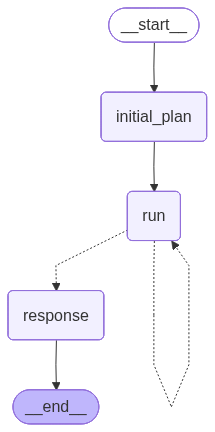

In [44]:
from typing import Annotated, TypedDict
import operator
from typing import Literal
from langchain.messages import HumanMessage
from langchain_core.prompts import PromptTemplate
from langgraph.graph import StateGraph, START, END

task = "Write a strategic one-pager of building an AI startup?"

class PlanState(TypedDict):
    task: str
    plan: Plan
    past_steps: Annotated[list[str], operator.add]
    final_response: str


def get_current_step(state: PlanState) -> int:
  """Returns the number of current step to be executed."""
  return len(state.get("past_steps", []))

def get_full_plan(state: PlanState) -> str:
  """Returns formatted plan with step numbers and past results."""
  full_plan = []
  for i, step in enumerate(state["plan"].steps):
    full_step = f"# {i+1}. Planned step: {step}\n"
    if i < get_current_step(state):
      full_step += f"Result: {state['past_steps'][i]}\n"
    full_plan.append(full_step)
  return "\n".join(full_plan)

final_prompt = PromptTemplate.from_template(
    "You're a helpful assistant that has executed on a plan."
    "Given the results of the execution, prepare the final response.\n"
    "Don't assume anything\nTASK:\n{task}\n\nPLAN WITH RESUlTS:\n{plan}\n"
    "FINAL RESPONSE:\n"
)

step_template = (
    "Given the task and the plan, try to execute on a specific step of the plan.\n"
    "TASK:\n{task}\n\nPLAN:\n{plan}\n\nSTEP TO EXECUTE:\n{step}\n"
)

async def _build_initial_plan(state: PlanState) -> PlanState:
  plan = await planner.ainvoke(state["task"])
  return {"plan": plan}

async def _run_step(state: PlanState) -> PlanState:
  plan = state["plan"]
  current_step_idx = get_current_step(state)
  current_step_text = plan.steps[current_step_idx]
  full_plan_text = get_full_plan(state)

  formatted_human_prompt = step_template.format(
    task=state["task"],
    plan=full_plan_text,
    step=current_step_text
  )

  step = await execution_agent.ainvoke(
      {
          "messages": [HumanMessage(content=formatted_human_prompt)],
          "task": state["task"],
          "plan": full_plan_text,
          "step": current_step_text,
      }
  )
  return {"past_steps": [step["messages"][-1].content]}

async def _get_final_response(state: PlanState) -> PlanState:
  final_response = await (final_prompt | llm).ainvoke({"task": state["task"], "plan": get_full_plan(state)})
  return {"final_response": final_response}


def _should_continue(state: PlanState) -> Literal["run", "response"]:
  if get_current_step(state) < len(state["plan"].steps):
    return "run"
  return "response"

builder = StateGraph(PlanState)
builder.add_node("initial_plan", _build_initial_plan)
builder.add_node("run", _run_step)
builder.add_node("response", _get_final_response)

builder.add_edge(START, "initial_plan")
builder.add_edge("initial_plan", "run")
builder.add_conditional_edges("run", _should_continue)
builder.add_edge("response", END)

graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

Run the agent:

In [45]:
task = "Write a strategic one-pager of building an AI startup"
result = await graph.ainvoke({"task": task})

print(result["final_response"].content)

## Transforming Youth Mental Health: Proactive AI for Personalized Well-being

### 1. The Problem & Our Unique Value Proposition

**Problem:** Young adults (18-29) face a mental health crisis exacerbated by inefficient, impersonal, and inaccessible traditional support. This leads to delayed interventions, poor outcomes, and persistent stigma.

**Unique Value Proposition:** We offer **AI-driven, hyper-personalized, and proactive mental well-being support.** Our privacy-first digital platform identifies early distress, delivering tailored, evidence-based interventions *before* issues escalate. This shifts care from reactive to continuous prevention, fostering long-term resilience and improved outcomes.

### 2. The AI-Powered Solution

Our multi-modal AI solution delivers continuous, proactive, and hyper-personalized mental well-being support:

*   **Core Technology:**
    *   **NLP & Sentiment Analysis:** Analyzes user input (journal entries, chat) to understand emotional states, themes,

Detailed run:

In [46]:
async for output in graph.astream({"task": task}, stream_mode="updates"):
    for key, value in output.items():
        print(f"Output from node '{key}':")
        print("---")
        print(value)
    print("\n---\n")

Output from node 'initial_plan':
---
{'plan': Plan(steps=['Define the core purpose and target audience for the one-pager (e.g., investors, partners, internal alignment).', 'Outline the key sections of a strategic one-pager for an AI startup (e.g., Vision/Mission, Problem, AI Solution, Market Opportunity, Competitive Advantage, Business Model, Team, Traction/Ask).', "Draft a compelling Vision and Mission statement that clearly articulates the startup's long-term goal and purpose.", 'Clearly identify and describe the specific problem the AI startup is addressing, emphasizing its significance and impact.', 'Detail the AI-powered solution, explaining how it works at a high level and what unique capabilities it offers to solve the identified problem.', 'Analyze and articulate the target market, including its size, growth potential, and customer segments.', "Describe the startup's competitive advantage(s), highlighting what makes its AI solution superior or unique compared to existing altern